### 4.4 SVAR — structural systems for both CPI measures

$$y_t = c + A_1y_{t-1} + A_2y_{t-2} + u_t,\quad u_t\sim(0,\Sigma)$$

$$\Sigma = PP',\qquad \varepsilon_t = P^{-1}u_t$$

$$\Theta_h = \Phi_h P$$

Two five-variable VAR(2)-in-levels systems (System A → `cpi_yoy`, System B →
`trimmed_mean_cpi_yoy`), recursive Cholesky ordering commodity growth → unemployment →
CPI target → business inflation expectations → cash rate, 80% contiguous block-bootstrap
IRF bands. **Read every panel below as illustrative, not causal** — both systems still
reject multivariate residual whiteness and normality after COVID treatment checks.

*Source: `src/models/svar.py`, exported to `reports/tableau/svar_irf.csv`*

#### Explained, step by step

- $y_t$ is a **vector** of five variables at once (commodity-price growth, unemployment, the CPI target, business inflation expectations, the cash rate) — not a single series like SARIMA. $A_1, A_2$ are $5\times5$ matrices saying how *all five* variables at $t-1$ and $t-2$ feed into *all five* variables at $t$; $c$ is a constant/intercept vector.
- $u_t$ is the vector of **reduced-form residuals** — the part of this quarter's movement the lagged history couldn't explain. $\Sigma$ is their covariance matrix: it captures that these five residuals are correlated *within* the same quarter (e.g. a bad quarter for commodity prices and a bad quarter for unemployment often coincide) — but a plain VAR can't say which one "caused" the other within that same quarter.
- $\Sigma = PP'$ is a **Cholesky decomposition**: splitting the correlated covariance matrix into a lower-triangular matrix $P$ such that $PP'$ reconstructs $\Sigma$. $\varepsilon_t = P^{-1}u_t$ then converts the correlated residuals $u_t$ into new shocks $\varepsilon_t$ that are, by construction, uncorrelated with each other — genuinely independent, "structural" shocks.
- The catch — why the app keeps warning "illustrative, not causal" — is that this decomposition requires imposing an **ordering**: here, commodity growth $\to$ unemployment $\to$ CPI target $\to$ business inflation expectations $\to$ cash rate. This encodes an assumption that a commodity-price shock can move unemployment *within the same quarter*, but a same-quarter cash-rate shock cannot instantaneously move commodity prices. That's a judgment call the data doesn't prove — a different, equally defensible ordering could shift the results.
- $\Theta_h = \Phi_h P$ is the **impulse response function (IRF)**: $\Phi_h$ (standard VAR theory) says how a shock to the *reduced-form* residuals propagates $h$ quarters forward; multiplying by $P$ converts that into "how does one unit of *structural* shock $\varepsilon$ (e.g. an independent unemployment surprise) move the CPI target $h$ quarters later, holding every other variable's same-quarter shock fixed." That's exactly what the IRF chart below plots.

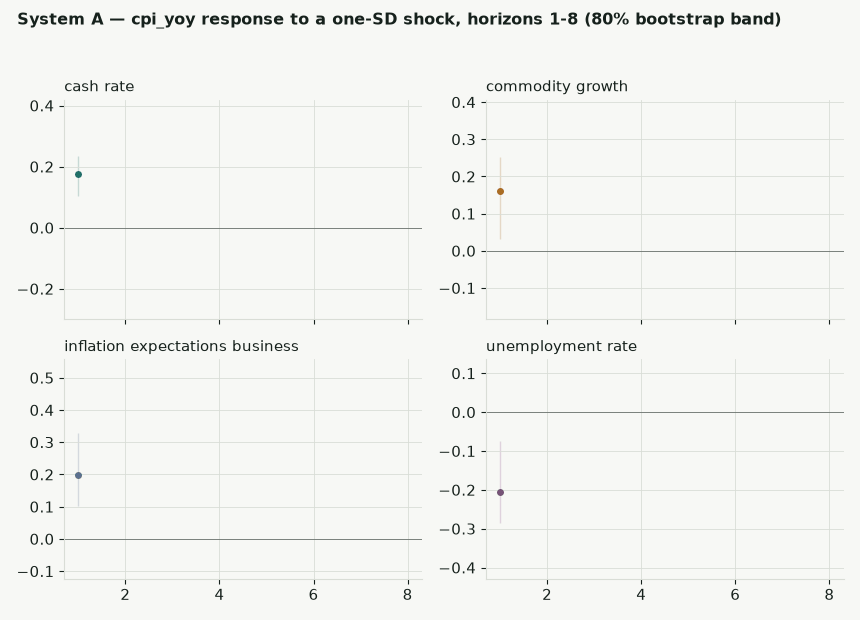

In [45]:
irf = pd.read_csv(PROJECT_ROOT / "reports/tableau/svar_irf.csv")
irf = irf[(irf["system"] == "System A") & (irf["response"] == "cpi_yoy")].copy()
shocks = sorted(irf["shock"].unique())
scolors = {shocks[0]: ACCENT, shocks[1]: HIGHLIGHT, shocks[2]: "#5b6f8f", shocks[3]: "#8a4f8a"}

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.2), sharex=True)
axes = axes.ravel()
lines, bands = [], []
for ax, shock in zip(axes, shocks):
    ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
    ax.set_title(shock.replace("_", " "), fontsize=10.5, loc="left")
    ax.set_xlim(0.7, 8.3)
    sub = irf[irf["shock"] == shock].sort_values("horizon")
    pad = 0.15 * (sub["upper"].max() - sub["lower"].min())
    ax.set_ylim(sub["lower"].min() - pad, sub["upper"].max() + pad)
    bands.append(ax.fill_between([], [], [], color=scolors[shock], alpha=0.22))
    line, = ax.plot([], [], color=scolors[shock], linewidth=2.0, marker="o", markersize=4)
    lines.append(line)
fig.suptitle("System A — cpi_yoy response to a one-SD shock, horizons 1-8 (80% bootstrap band)",
             fontsize=11.5, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))

def update_irf(h):
    for i, shock in enumerate(shocks):
        sub = irf[irf["shock"] == shock].sort_values("horizon")
        sub = sub[sub["horizon"] <= h]
        lines[i].set_data(sub["horizon"], sub["irf"])
        bands[i].remove()
        bands[i] = axes[i].fill_between(sub["horizon"], sub["lower"], sub["upper"], color=scolors[shock], alpha=0.22)
    return lines

anim_irf = animation.FuncAnimation(fig, update_irf, frames=list(range(1, 9)) + [8] * 6, interval=350, blit=False)
gif_path = PROJECT_ROOT / "notebooks/assets/svar_animation.gif"
gif_path.parent.mkdir(parents=True, exist_ok=True)
anim_irf.save(gif_path, writer=animation.PillowWriter(fps=3))
plt.close(fig)
Image(filename=str(gif_path))